<a href="https://colab.research.google.com/github/omertahakerem/statistical-analysis-II-homework/blob/main/homework_2/python/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Türkçe

Bu çalışmada, eğitim öncesi ve eğitim sonrası test sonuçları kullanılarak öğrencilerin başarı düzeyinde anlamlı bir değişim olup olmadığı incelenmiştir. Analiz kapsamında öncelikle fark değişkeninin normal dağılıma uygunluğu test edilmiş, ardından uygun istatistiksel yöntem seçilerek analiz gerçekleştirilmiştir.

English

In this study, pre-training and post-training test scores were used to examine whether there was a significant change in student performance. First, the normality of the difference variable was tested, and then the appropriate statistical method was applied.

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!git clone https://github.com/omertahakerem/statistical-analysis-II-homework.git


Cloning into 'statistical-analysis-II-homework'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 15 (delta 2), reused 9 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 296.09 KiB | 3.80 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [6]:
%cd /content/statistical-analysis-II-homework


/content/statistical-analysis-II-homework


In [7]:
!touch analysis.ipynb

In [8]:
! ls


analysis.docx	analysis.pdf  paired-analysis.R  project.Rproj
analysis.ipynb	analysis.Rmd  paired_veri.xlsx	 README.md


In [18]:
import pandas as pd

df = pd.read_excel("paired_veri.xlsx", sheet_name=2)
df.head()

,Veri 61,Veri 62,Veri 63,Veri 64,Veri 65,Veri 66,Veri 67,Veri 68,Veri 69,Veri 70,...,Veri 111,Veri 112,Veri 113,Veri 114,Veri 115,Veri 116,Veri 117,Veri 118,Veri 119,Veri 120
0,48.8952,67.6290,56.6473,63.6005,61.9911,73.3805,56.8098,66.0532,52.8925,65.8321,...,66.7712,62.8045,50.0650,68.7607,64.5225,69.4372,61.3315,65.4645,56.9933,64.6058
1,64.3685,70.4883,73.5525,80.5977,59.5307,60.7140,70.1744,67.4395,66.2123,56.6689,...,67.0879,71.4931,62.4449,70.1864,58.7115,53.9551,72.6177,66.6636,68.9666,67.6751
2,73.3168,74.9907,73.7523,63.9869,54.4481,56.4525,64.7510,75.2946,64.2483,62.6287,...,65.9172,77.6879,71.7569,70.3306,65.3316,65.2567,64.4172,55.1953,69.9162,64.6002
3,71.8814,63.7498,72.5590,64.1566,55.6788,59.8224,61.7234,67.1188,63.3071,65.1901,...,59.0450,64.6231,65.7992,66.8487,69.4840,64.7332,71.9883,57.4902,69.8668,60.8455
4,71.2269,60.8781,58.4956,66.9351,59.5563,62.1661,72.8472,71.5642,68.6300,68.9358,...,71.3265,65.4867,60.8004,53.9076,58.9162,61.4199,63.5470,66.0574,64.9938,61.6994


In [20]:
print(df.columns)
print(df.head())

Index(['Veri 61', 'Veri 62', 'Veri 63', 'Veri 64', 'Veri 65', 'Veri 66',
       'Veri 67', 'Veri 68', 'Veri 69', 'Veri 70', 'Veri 71', 'Veri 72',
       'Veri 73', 'Veri 74', 'Veri 75', 'Veri 76', 'Veri 77', 'Veri 78',
       'Veri 79', 'Veri 80', 'Veri 81', 'Veri 82', 'Veri 83', 'Veri 84',
       'Veri 85', 'Veri 86', 'Veri 87', 'Veri 88', 'Veri 89', 'Veri 90',
       'Veri 91', 'Veri 92', 'Veri 93', 'Veri 94', 'Veri 95', 'Veri 96',
       'Veri 97', 'Veri 98', 'Veri 99', 'Veri 100', 'Veri 101', 'Veri 102',
       'Veri 103', 'Veri 104', 'Veri 105', 'Veri 106', 'Veri 107', 'Veri 108',
       'Veri 109', 'Veri 110', 'Veri 111', 'Veri 112', 'Veri 113', 'Veri 114',
       'Veri 115', 'Veri 116', 'Veri 117', 'Veri 118', 'Veri 119', 'Veri 120'],
      dtype='object')
   Veri 61  Veri 62  Veri 63  Veri 64  Veri 65  Veri 66  Veri 67  Veri 68  \
0  48.8952  67.6290  56.6473  63.6005  61.9911  73.3805  56.8098  66.0532   
1  64.3685  70.4883  73.5525  80.5977  59.5307  60.7140  70.1744  67.439

In [22]:
veri = df["Veri 69"]

once = veri.iloc[:20].reset_index(drop=True)
sonra = veri.iloc[20:40].reset_index(drop=True)

print("Önce:")
print(once)

print("\nSonra:")
print(sonra)

Önce:
0     52.8925
1     66.2123
2     64.2483
3     63.3071
4     68.6300
5     65.3856
6     65.4959
7     65.4995
8     53.6690
9     57.8059
10    66.1320
11    59.9779
12    71.1303
13    55.3555
14    70.9029
15    70.0585
16    64.7811
17    69.8152
18    73.4207
19    64.1530
Name: Veri 69, dtype: float64

Sonra:
0     56.6615
1     69.1464
2     68.6359
3     72.2385
4     63.0881
5     68.2150
6     57.4382
7     66.9029
8     68.2813
9     61.6607
10    67.2018
11    85.8888
12    66.9881
13    68.5258
14    63.7914
15    60.7229
16    64.4803
17    74.5548
18    63.9036
19    61.1870
Name: Veri 69, dtype: float64


In [23]:
fark = sonra - once

print(fark)

0      3.7690
1      2.9341
2      4.3876
3      8.9314
4     -5.5419
5      2.8294
6     -8.0577
7      1.4034
8     14.6123
9      3.8548
10     1.0698
11    25.9109
12    -4.1422
13    13.1703
14    -7.1115
15    -9.3356
16    -0.3008
17     4.7396
18    -9.5171
19    -2.9660
Name: Veri 69, dtype: float64


Türkçe

Bu aşamada, eğitim öncesi ve eğitim sonrası puanlar arasındaki farkların normal dağılıma uygun olup olmadığını incelemek için Shapiro-Wilk normallik testi uygulanacaktır. Eşleştirilmiş örneklemlerde hangi testin kullanılacağına karar verebilmek için fark değişkeninin dağılımı kontrol edilmelidir.

English

At this stage, the Shapiro-Wilk normality test will be applied to examine whether the differences between pre-training and post-training scores follow a normal distribution. In paired samples, the distribution of the difference variable should be checked in order to determine the appropriate test.

In [29]:


from scipy.stats import shapiro

stat, p = shapiro(fark)

print("Shapiro-Wilk Test İstatistiği:", stat)
print("p-değeri:", p)



Shapiro-Wilk Test İstatistiği: 0.9249552621923369
p-değeri: 0.12344887746590416


Türkçe

Bu aşamada, eğitim öncesi ve eğitim sonrası puanlar arasındaki farkların normal dağılıma uygun olup olmadığını incelemek amacıyla Shapiro-Wilk normallik testi uygulanmıştır. Yapılan test sonucunda p-değeri 0.12 olarak elde edilmiştir. Bu değer 0.05 anlamlılık düzeyinden büyük olduğu için fark değişkeninin normal dağıldığı kabul edilir. Bu nedenle analizde parametrik yöntemlerin kullanılmasına karar verilmiştir.

English

At this stage, the Shapiro-Wilk normality test was applied to examine whether the differences between pre-training and post-training scores follow a normal distribution. The test resulted in a p-value of 0.12. Since this value is greater than the significance level of 0.05, the difference variable is considered to be normally distributed. Therefore, it was decided to use parametric methods in the analysis.

Türkçe

Normallik varsayımı sağlandığı için eğitim öncesi ve eğitim sonrası puanlar arasındaki farkı incelemek amacıyla eşleştirilmiş örneklem t-testi uygulanacaktır.

English

Since the normality assumption is satisfied, the paired sample t-test will be applied to examine the difference between pre-training and post-training scores.

In [26]:
from scipy.stats import ttest_rel

stat, p = ttest_rel(sonra, once)

print("Test istatistiği:", stat)
print("p-değeri:", p)

Test istatistiği: 1.02409997085418
p-değeri: 0.31865091585543703


Türkçe

Eşleştirilmiş örneklem t-testi sonucunda p-değeri 0.31 olarak bulunmuştur. Bu değer 0.05 anlamlılık düzeyinden büyük olduğu için sıfır hipotezi reddedilemez. Buna göre eğitim öncesi ve eğitim sonrası test puanları arasında istatistiksel olarak anlamlı bir fark bulunmamaktadır. Bu sonuç, uygulanan eğitimin öğrenci başarısı üzerinde anlamlı bir etkisinin olmadığını göstermektedir.

English

According to the paired sample t-test, the p-value was found to be 0.31. Since this value is greater than the significance level of 0.05, the null hypothesis cannot be rejected. Therefore, there is no statistically significant difference between pre-training and post-training test scores. This result indicates that the training did not have a significant effect on student performance.

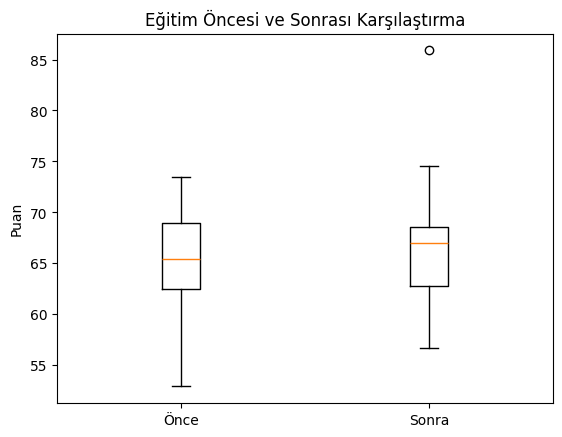

In [27]:
import matplotlib.pyplot as plt

plt.boxplot([once, sonra])
plt.xticks([1, 2], ["Önce", "Sonra"])
plt.title("Eğitim Öncesi ve Sonrası Karşılaştırma")
plt.ylabel("Puan")
plt.show()

Türkçe

Kutu grafiği incelendiğinde eğitim öncesi ve eğitim sonrası puan dağılımlarının birbirine oldukça yakın olduğu görülmektedir. Medyan ve dağılım değerleri arasında belirgin bir fark bulunmamaktadır. Bu görsel bulgular, yapılan eşleştirilmiş örneklem t-testi sonucuyla uyumludur ve eğitim sonrasında anlamlı bir değişim olmadığını desteklemektedir.

English

The boxplot indicates that the distributions of pre-training and post-training scores are quite similar. There is no clear difference between the median and the spread of the data. These visual findings are consistent with the results of the paired t-test and support the conclusion that there is no significant change after the training.Türkçe

Kutu grafiği incelendiğinde eğitim öncesi ve eğitim sonrası puan dağılımlarının birbirine oldukça yakın olduğu görülmektedir. Medyan ve dağılım değerleri arasında belirgin bir fark bulunmamaktadır. Bu görsel bulgular, yapılan eşleştirilmiş örneklem t-testi sonucuyla uyumludur ve eğitim sonrasında anlamlı bir değişim olmadığını desteklemektedir.

English

The boxplot indicates that the distributions of pre-training and post-training scores are quite similar. There is no clear difference between the median and the spread of the data. These visual findings are consistent with the results of the paired t-test and support the conclusion that there is no significant change after the training.